# Simulate time histories of wave excitation



This example demonstrates how to simulate time histories of wave excitation forces acting on the pontoons of a floating structure (e.g. a floating bridge). The simulation is based on a spectral approach: a directional wave spectrum (JONSWAP) is defined for a given sea state, and the corresponding frequency-domain wave excitation forces are computed from hydrodynamic coefficients. These are then used to generate correlated, multi-DOF time series via spectral simulation.

The workflow covers:
1. Loading hydrodynamic data for a pontoon type (added mass, damping, wave excitation transfer functions)
2. Defining pontoon positions and orientations along a curved bridge alignment
3. Specifying a JONSWAP sea state with directional spreading
4. Assembling the hydrodynamic model and visualising the structure
5. Evaluating the wave excitation cross-spectral density matrix
6. Simulating and plotting time histories of all six force/moment components at each pontoon

In [1]:
from wawi.model import Model, Hydro, Seastate, Pontoon, PontoonType, Node
from wawi.time_domain import simulate_mdof
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

## Pontoon type
The hydrodynamic properties of a single pontoon are loaded from a pre-computed `.npz` file (e.g. from a panel code such as WAMIT or HydroD). This includes:
- **A**: frequency-dependent added mass matrix (6×6 per frequency)
- **B**:  radiation damping matrix (6×6 per frequency)
- **Q**: wave excitation force transfer function (6 DOFs × wave directions × frequencies)

A `PontoonType` object is created from these arrays and associated with a mesh file (`.stl`) used for visualisation.

In [2]:
# Import hydrodynamic results for pontoon (`PontoonType`)
data = np.load('./input/ptype_1.npz')
A, B, omega, Q, thetaQ, omegaQ = data['M'], data['C'], data['omega'], data['Q'], data['theta_Q'], data['omega_Q']
pontoon_type = PontoonType.from_numeric(A=A, B=B, Q=Q, theta=thetaQ, omegaQ=omegaQ, omega=omega, stl_path='./input/pontoon.stl')

## Pontoon
These pontoon types are used to define the behaviour of all pontoons. The `Pontoon` objects are created and placed in a list:

In [3]:
# Define list of pontoons (generated at arbitrary locations)
x = np.arange(0,400+100,100)
y = np.sin(x)*100
z = x*0
rot = np.linspace(0, 10.0/2/np.pi, len(x))

pontoons = [Pontoon(Node(ix, x[ix], y[ix], z[ix]), pontoon_type, rotation=rot[ix]) for ix in range(len(x))]

## Sea state
The sea state is described by a JONSWAP spectrum with directional spreading. Key parameters:
- **Tp**: peak period [s]
- **Hs**: significant wave height [m]
- **gamma**: JONSWAP peak enhancement factor (γ = 1 gives a Pierson-Moskowitz spectrum)
- **theta0**: principal wave direction [degrees]
- **s**: directional spreading exponent (higher values = more concentrated directional energy)

In [4]:
# Define Seastate
Tp = 3.0 
Hs = 2.1 
gamma = 4.0

theta0 = 90.0
s = 31

seastate = Seastate(Tp, Hs, gamma, theta0, s=s)

In [5]:
# Define Hydro object
hydro = Hydro(pontoons=pontoons, seastate=seastate)

In [6]:
# Combine and build model
model = Model(hydro=hydro, seastate=seastate, avoid_eldef=True)
pl = model.plot(show=False, show_logo=True, )
pl.view_xy()
pl.camera.zoom(6.0)
pl.show()

Widget(value='<iframe src="http://localhost:53595/index.html?ui=P_0x1e8eec09070_0&reconnect=auto" class="pyvis…

## Wave excitation cross-spectral density and time simulation
The wave excitation cross-spectral density (CPSD) matrix `Sqq` is evaluated at each frequency in `omega`. This matrix captures both the auto-spectral content (how energetic each force component is) and the cross-spectral correlations between force components at different pontoons (spatial coherence driven by the wave field).

`simulate_mdof` uses the CPSD matrix to generate correlated time histories via spectral simulation (Cholesky decomposition + random phase angles). The result `q` has shape `(n_dof, n_timesteps)` where `n_dof = 6 × n_pontoons`.

In [7]:
omega = np.arange(0.05, 2.0, 0.05)
Sqq = model.evaluate_waveaction(omega)

q, t = simulate_mdof(Sqq, omega, fs=10.0, tmax=300)

[ ==================== ] 100% ESTABLISHING WAVE EXCITATION     

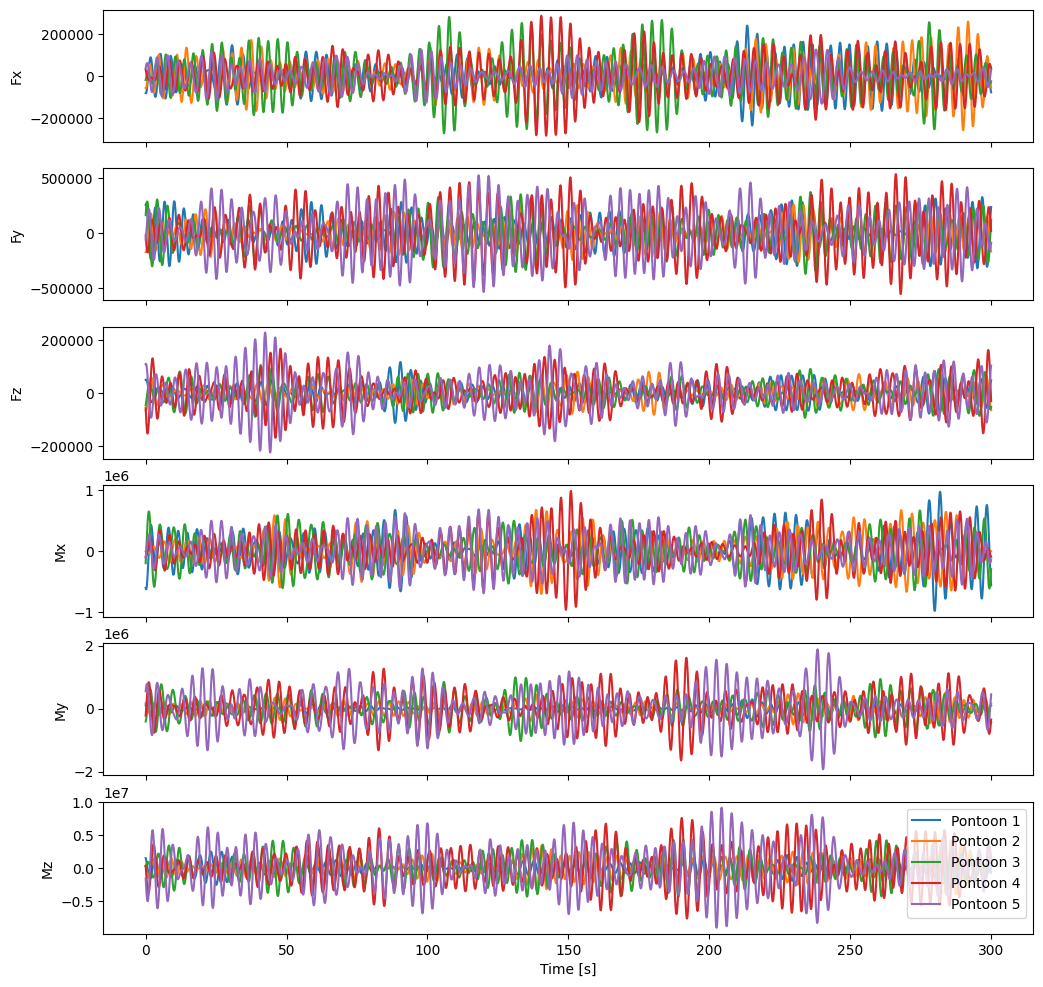

In [8]:
fig,ax = plt.subplots(nrows=6, figsize=(12,12), sharex=True)
dof_strs = ['Fx', 'Fy', 'Fz', 'Mx', 'My', 'Mz']
for dof_ix in range(6):
    for pontoon_ix in range(len(pontoons)):
        ax[dof_ix].plot(t, q[pontoon_ix*6+dof_ix,:], label=f'Pontoon {pontoon_ix+1}')
        
    ax[dof_ix].set_ylabel(dof_strs[dof_ix])

ax[dof_ix].legend()
ax[-1].set_xlabel('Time [s]');

The six force/moment components (Fx, Fy, Fz, Mx, My, Mz) are plotted for all pontoons. Note that the forces are expressed in the local pontoon coordinate system. The spatial variation between pontoons reflects the wave phase differences arising from their positions along the bridge alignment.

A global representation could easily be created utilizing the transformation matrices structured in the `Model` object:

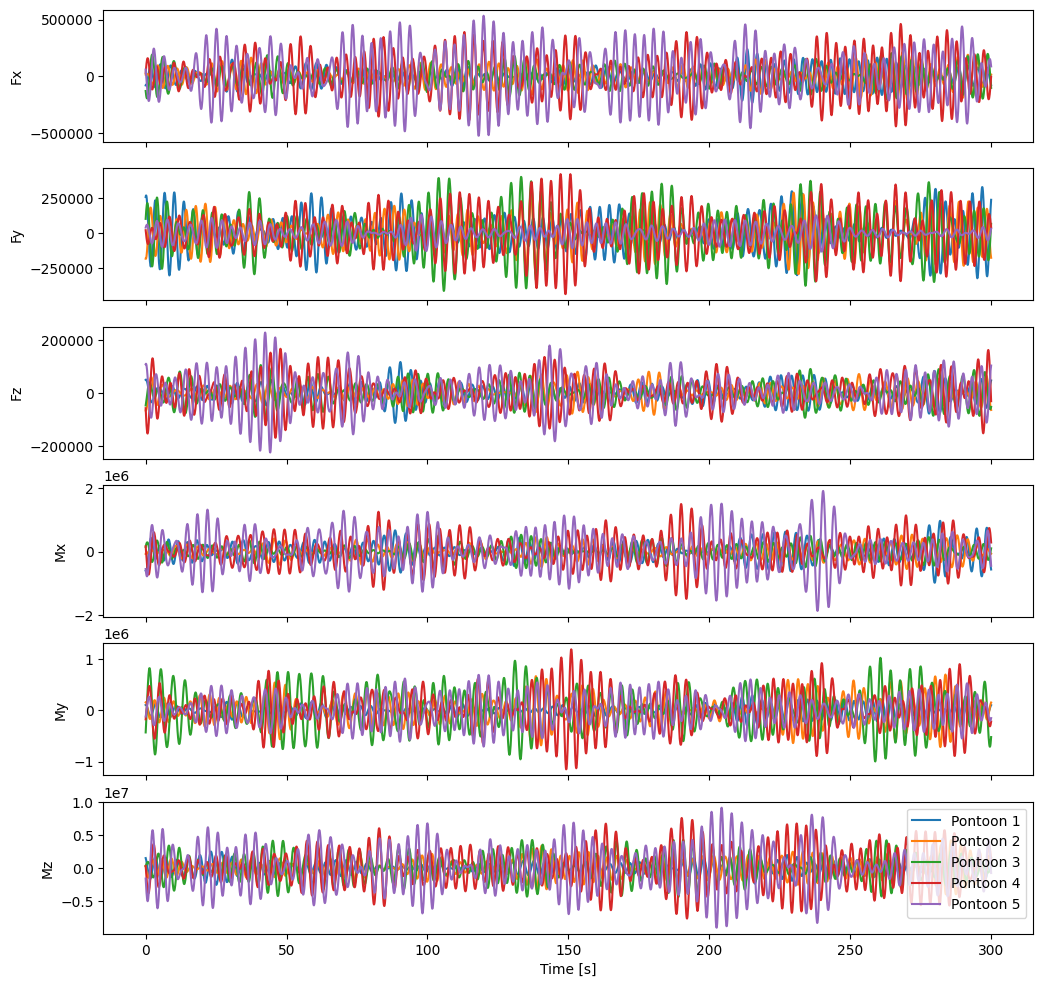

In [10]:
T = model.hydro.get_from_all('tmat')
Ttot = block_diag(*T)

Q = (Ttot.T @ q)

fig,ax = plt.subplots(nrows=6, figsize=(12,12), sharex=True)
dof_strs = ['Fx', 'Fy', 'Fz', 'Mx', 'My', 'Mz']
for dof_ix in range(6):
    for pontoon_ix in range(len(pontoons)):
        ax[dof_ix].plot(t, Q[pontoon_ix*6+dof_ix,:], label=f'Pontoon {pontoon_ix+1}')
        
    ax[dof_ix].set_ylabel(dof_strs[dof_ix])

ax[dof_ix].legend()
ax[-1].set_xlabel('Time [s]');